# Vanilla LSTM — RUL Prediction on CMAPSS (PyTorch)

This notebook trains and evaluates a Vanilla LSTM for Remaining Useful Life (RUL)
prediction on all CMAPSS Datasets, implemented in **PyTorch**.

The PyTorch framework is chosen as the foundation for this and all subsequent models
in this project, given its dominance in graph neural network research (PyTorch Geometric,
DGL) which forms the later stages of the project (hopefully).

## Notebook Structure
1. Configuration
2. Imports and reproducibility
3. Dataset and DataLoader
4. Data inspection
5. Evaluation metrics (RMSE + NASA scoring function)
6. Architecture definition
7. Training loop
8. Evaluation and results

> **Prerequisite:** Run `preprocessing.ipynb` first to generate the `.npy` files in `preprocessed/`.

## 1. Configuration

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────

PREPROCESSED_DIR = 'preprocessed/'   # output folder from preprocessing.ipynb
DATASETS         = ['FD001', 'FD002_unified', 'FD002_clustered', 'FD003', 'FD004_unified', 'FD004_clustered']

SEED             = 42

# Training hyperparameters
BATCH_SIZE       = 256
EPOCHS           = 100
LEARNING_RATE    = 1e-3
VALIDATION_SPLIT = 0.1               # fraction of training data held out for validation

# ──────────────────────────────────────────────────────────────────────────────

## 2. Imports and Reproducibility

In PyTorch, reproducibility requires seeding `torch`, `numpy`, and Python's `random`
separately. We also set `torch.backends.cudnn.deterministic = True` to ensure
deterministic CUDA operations when running on GPU.

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # I encounter ExitCode: 3, Reason: OMP runtime error in the notebook and this is what I found as the workaround talking with Claude.ai.
# Claude says: "In a research/student context this is fine — the risk of incorrect results it warns about is relevant to heavy parallel numerical computing, not sequential LSTM training on a modest dataset."

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import GroupShuffleSplit, GroupKFold

import pandas as pd


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Seed            : {SEED}")


PyTorch version : 2.10.0+cpu
Device          : cpu
Seed            : 42


## 3. Dataset and DataLoader

PyTorch's `Dataset` / `DataLoader` pattern handles batching, shuffling, and
multi-worker loading. We wrap the numpy arrays in a lightweight `CMAPSSDataset`
class that converts them to `float32` tensors on demand.

### Engine-grouped train / validation split

The training set is split into train / validation by **holding out engines**,
not random samples. Concretely, we use `sklearn.model_selection.GroupShuffleSplit`
with `engine_ids_train.npy` (saved by `preprocessing.ipynb`) as the grouping
variable, and a fixed `random_state` for reproducibility.

A naive sample-level split (e.g. `random_split` over already-windowed data) is
unsafe here for two reasons:

1. **Window overlap.** With stride 1 and window size $W$, consecutive windows from
   one engine share $W{-}1$ timesteps and have nearly identical RUL labels.
   Random splitting almost always lands such pairs on opposite sides of the
   train/val boundary, so the validation loss measures interpolation between
   already-seen sequences rather than generalisation.

2. **Engine identity.** Per-unit characteristics (initial wear, sensor offsets,
   noise patterns) can be memorised. Because the CMAPSS test set is composed of
   completely held-out engines, the validation set must mirror that protocol
   for its loss to be a faithful proxy for test performance.

This follows the engine-grouped 90/10 protocol used by Costa & Sánchez (2021)
on CMAPSS, and the general principle from Hastie et al., *Elements of
Statistical Learning* §7.10: cross-validation must be applied to the entire
modelling pipeline — held-out samples are carved out *before* any feature
engineering or windowing step that could couple them to the training data.

The same machinery exposes `engine_grouped_kfold(...)` for k-fold CV during
hyperparameter tuning (see §7.x).

Note that `batch_first=True` must be set on `nn.LSTM` to match the tensor layout
that `DataLoader` produces: `(batch, timesteps, features)`.


In [3]:
class CMAPSSDataset(Dataset):
    """
    Wraps preprocessed CMAPSS numpy arrays into a PyTorch Dataset.

    Each item is a tuple (x, y) where:
        x : FloatTensor of shape (window_size, n_features)
        y : FloatTensor scalar representing the RUL label
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()   # (N, T, F)
        self.y = torch.from_numpy(y).float()   # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def engine_grouped_split(engine_ids, val_fraction=VALIDATION_SPLIT, seed=SEED):
    """
    Single 90/10 engine-grouped train/val split.

    Returns
    -------
    train_idx, val_idx : np.ndarray
        Sample-level indices into the windowed arrays such that the set of
        engines present in `train_idx` is disjoint from those in `val_idx`.

    Why this matters
    ----------------
    Windowed CMAPSS data has two leakage paths under naive random splitting:
      (1) Overlapping windows: with stride 1 and window=W, consecutive samples
          share W-1 timesteps. A random split places near-identical windows
          on both sides, making val loss trivially low.
      (2) Engine identity: per-unit idiosyncrasies (initial wear, sensor
          offsets, noise patterns) can be memorised; the test set is composed
          of completely held-out engines, so the val set must be too.

    Holding out *engines* (groups) at split time fixes both. cf. Costa &
    Sánchez (Attention+LSTM for RUL, 2021) for the same protocol on CMAPSS,
    and Hastie, Tibshirani & Friedman (Elements of Statistical Learning, §7.10)
    for the general principle: cross-validation must be applied to the
    full pipeline, with held-out samples carved out *before* any
    transformation that could couple them to the rest.
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(splitter.split(X=np.zeros(len(engine_ids)),
                                             groups=engine_ids))
    return train_idx, val_idx


def engine_grouped_kfold(engine_ids, n_splits=5):
    """
    Generator yielding (train_idx, val_idx) pairs for engine-grouped K-fold CV.

    Drop-in replacement for `engine_grouped_split` when running k-fold
    hyperparameter search. Note: GroupKFold is deterministic (it does not
    shuffle), so the same engine_ids -> same folds. For shuffled folds,
    swap to StratifiedGroupKFold or a manual permutation of engine ids.

    Usage
    -----
    >>> for fold, (tr, va) in enumerate(engine_grouped_kfold(engine_ids, n_splits=5)):
    ...     train_loader, val_loader = build_loaders_from_indices(full_ds, tr, va)
    ...     # ... train, evaluate, log per-fold metrics ...
    """
    splitter = GroupKFold(n_splits=n_splits)
    yield from splitter.split(X=np.zeros(len(engine_ids)), groups=engine_ids)


def build_loaders_from_indices(full_dataset, train_idx, val_idx,
                               batch_size=BATCH_SIZE):
    """Wrap two index arrays into shuffled-train / non-shuffled-val DataLoaders."""
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def load_dataset(preprocessed_dir, dataset):
    """
    Load numpy arrays from disk and return train/val/test DataLoaders
    alongside feature column names and raw arrays.

    Train/val split is engine-grouped (see `engine_grouped_split`).
    """
    p = os.path.join(preprocessed_dir, dataset)

    X_train_all  = np.load(f'{p}_X_train.npy')
    y_train_all  = np.load(f'{p}_y_train.npy')
    engine_ids   = np.load(f'{p}_engine_ids_train.npy')
    X_test       = np.load(f'{p}_X_test.npy')
    y_test       = np.load(f'{p}_y_test.npy')
    feature_cols = list(np.load(f'{p}_feature_cols.npy'))

    # ── Engine-grouped train/val split ───────────────────────────────────────
    train_idx, val_idx = engine_grouped_split(engine_ids,
                                              val_fraction=VALIDATION_SPLIT,
                                              seed=SEED)

    full_dataset = CMAPSSDataset(X_train_all, y_train_all)
    train_loader, val_loader = build_loaders_from_indices(full_dataset,
                                                          train_idx, val_idx)
    test_loader = DataLoader(CMAPSSDataset(X_test, y_test),
                             batch_size=BATCH_SIZE, shuffle=False)

    # Sanity: engine sets must be disjoint
    train_engines = set(engine_ids[train_idx].tolist())
    val_engines   = set(engine_ids[val_idx].tolist())
    assert train_engines.isdisjoint(val_engines), \
        "Engine leakage between train and val — split is broken."

    raw = {
        'X_train': X_train_all, 'y_train': y_train_all,
        'X_test':  X_test,      'y_test':  y_test,
        'engine_ids':   engine_ids,
        'train_idx':    train_idx,
        'val_idx':      val_idx,
        'train_engines': sorted(train_engines),
        'val_engines':   sorted(val_engines),
        'feature_cols': feature_cols,
    }
    return train_loader, val_loader, test_loader, raw


# ── Load all datasets ─────────────────────────────────────────────────────────
loaders = {}
arrays  = {}

for ds in DATASETS:
    tr_loader, val_loader, te_loader, raw = load_dataset(PREPROCESSED_DIR, ds)
    loaders[ds] = {'train': tr_loader, 'val': val_loader, 'test': te_loader}
    arrays[ds]  = raw

    n_features  = raw['X_train'].shape[2]
    window_size = raw['X_train'].shape[1]
    n_train_eng = len(raw['train_engines'])
    n_val_eng   = len(raw['val_engines'])
    n_train_win = len(raw['train_idx'])
    n_val_win   = len(raw['val_idx'])
    print(f"\n{ds}")
    print(f"  Input shape       : (batch, {window_size}, {n_features})")
    print(f"  Train samples     : {len(raw['X_train'])}  "
          f"-> train batches: {len(tr_loader)}, val batches: {len(val_loader)}")
    print(f"  Engine split      : {n_train_eng} train engines / {n_val_eng} val engines "
          f"({n_train_win} / {n_val_win} windows)")
    print(f"  Test engines      : {len(raw['X_test'])}")
    print(f"  Features ({n_features})    : {raw['feature_cols']}")



FD001
  Input shape       : (batch, 30, 15)
  Train samples     : 17731  -> train batches: 62, val batches: 8
  Engine split      : 90 train engines / 10 val engines (15847 / 1884 windows)
  Test engines      : 100
  Features (15)    : [np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('htBleed'), np.str_('W31'), np.str_('W32')]

FD002_unified
  Input shape       : (batch, 20, 21)
  Train samples     : 48819  -> train batches: 173, val batches: 19
  Engine split      : 234 train engines / 26 val engines (44130 / 4689 windows)
  Test engines      : 259
  Features (21)    : [np.str_('T2'), np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P2'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('epr'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('farB'), np.str_('htBleed

## 4. Data Inspection

Sanity checks before touching the model: NaN presence, value ranges after scaling,
and RUL label distributions.

In [6]:
for ds in DATASETS:
    X_tr = arrays[ds]['X_train']
    y_tr = arrays[ds]['y_train']
    X_te = arrays[ds]['X_test']
    y_te = arrays[ds]['y_test']

    print(f"\n── {ds} ────────────────────────────────────")
    print(f"  NaNs  X_train / X_test : {np.isnan(X_tr).sum()} / {np.isnan(X_te).sum()}")
    print(f"  X_train range : [{X_tr.min():.3f},  {X_tr.max():.3f}]")
    print(f"  X_test  range : [{X_te.min():.3f},  {X_te.max():.3f}]  "
          f"(may exceed [0, 1] — scaler was fit on train only)")
    print(f"  y_train range : [{y_tr.min():.1f}, {y_tr.max():.1f}]  (expected [0, 125])")
    print(f"  y_test  range : [{y_te.min():.1f}, {y_te.max():.1f}]")


── FD001 ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [7.0, 145.0]

── FD002_unified ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [6.0, 194.0]

── FD002_clustered ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [-0.062,  1.000]  (may exceed [0, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [6.0, 194.0]

── FD003 ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : 

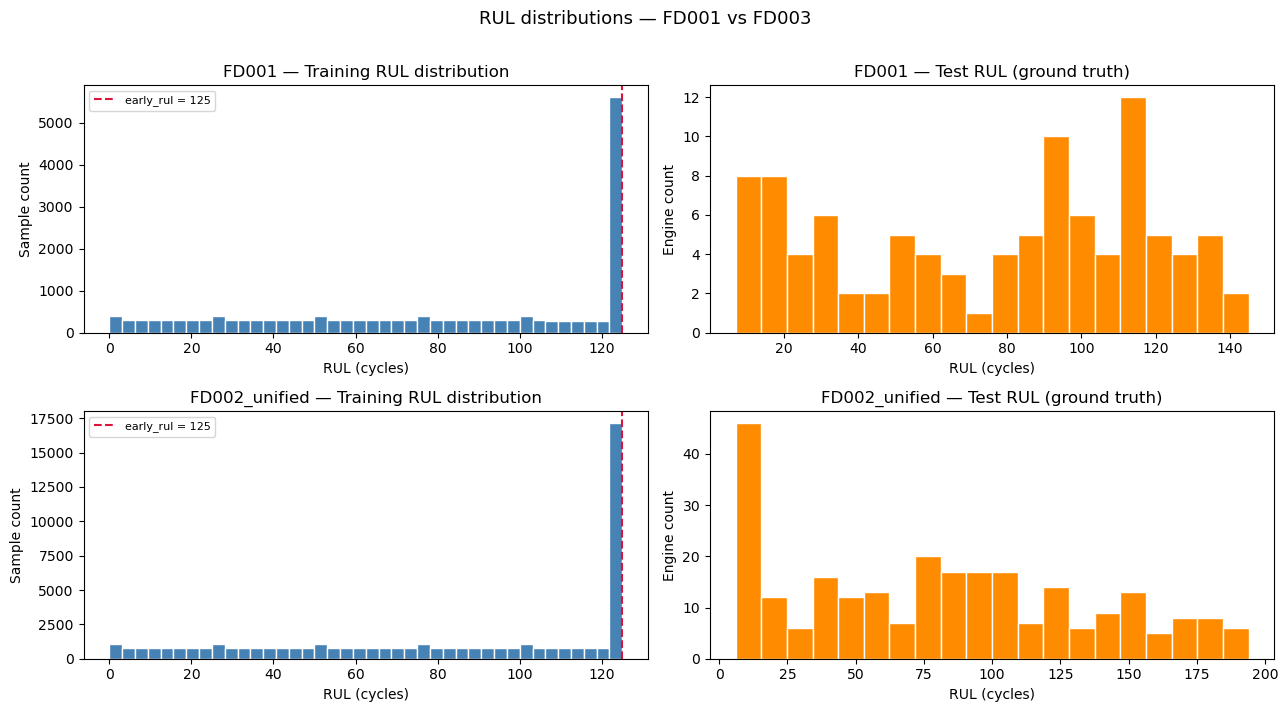

In [7]:
fig, axes = plt.subplots(len(DATASETS[:2]), 2, figsize=(13, 7))

for row, ds in enumerate(DATASETS[:2]):
    y_tr = arrays[ds]['y_train']
    y_te = arrays[ds]['y_test']

    axes[row, 0].hist(y_tr, bins=40, color='steelblue', edgecolor='white')
    axes[row, 0].axvline(125, color='crimson', linestyle='--', label='early_rul = 125')
    axes[row, 0].set_title(f'{ds} — Training RUL distribution')
    axes[row, 0].set_xlabel('RUL (cycles)')
    axes[row, 0].set_ylabel('Sample count')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].hist(y_te, bins=20, color='darkorange', edgecolor='white')
    axes[row, 1].set_title(f'{ds} — Test RUL (ground truth)')
    axes[row, 1].set_xlabel('RUL (cycles)')
    axes[row, 1].set_ylabel('Engine count')

plt.suptitle('RUL distributions — FD001 vs FD003', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'rul_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation Metrics

Two standard metrics from the CMAPSS literature are used throughout:

### RMSE
Symmetric, penalises large errors quadratically. Primary benchmark across all papers
including Li et al. (2018) and Da Costa et al. (2019).

From Da Costa et al. (2019) section 3.5 "Loss Function":

$$\mathcal{L}^i(\theta)=||\hat{y}_{t+1}^i - y_{t+1}^i||^2$$

### NASA Asymmetric Scoring Function
Proposed by Saxena et al. (2008) in the original CMAPSS benchmark paper and used
in virtually all subsequent work. Defined as:

$$S = \sum_{i=1}^{N} s_i, \qquad s_i = \begin{cases} e^{-d_i/13} - 1 & d_i < 0 \quad \text{(early prediction)} \\ e^{d_i/10} - 1 & d_i \geq 0 \quad \text{(late prediction)} \end{cases}$$

where $d_i = \hat{y}_i - y_i$. The asymmetry is physically motivated: a late
warning leaves no time to act, so overestimating RUL is penalised more harshly.

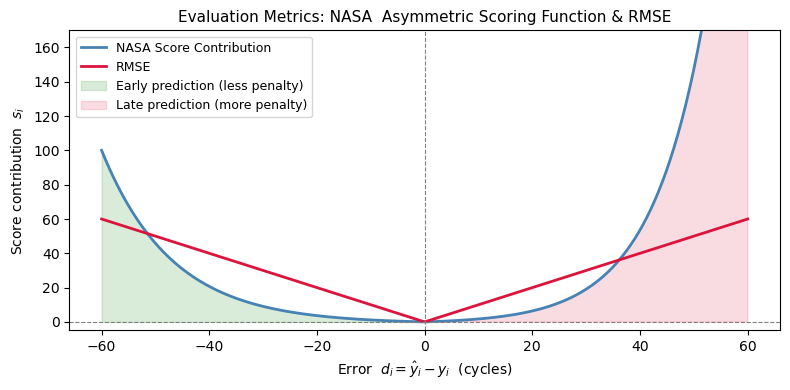

In [8]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def nasa_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    NASA asymmetric scoring function (Saxena et al., 2008).
    Penalises late predictions (d > 0) more harshly than early ones.
    Lower is better.
    """
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1,
                         np.exp( d / 10) - 1)
    return float(np.sum(s))


def evaluate(model: nn.Module, loader: DataLoader):
    """
    Run inference over a DataLoader.
    Returns (y_true, y_pred) as numpy arrays, ready for metric functions.
    Model is set to eval mode and no gradients are computed.
    """
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            output  = model(X_batch).squeeze(-1).cpu().numpy()
            preds.append(output)
            targets.append(y_batch.numpy())

    return np.concatenate(targets), np.concatenate(preds)


# ── Visualise the scoring function shape ──────────────────────────────────────
d_range = np.linspace(-60, 60, 500)
s_vals  = np.where(d_range < 0, np.exp(-d_range / 13) - 1,
                                 np.exp( d_range / 10) - 1)
rmse_vals = np.abs(d_range)  # RMSE contribution is just the absolute error (since it's squared and then rooted, the shape is linear)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(d_range, s_vals, color='steelblue', linewidth=2, label='NASA Score Contribution')
ax.plot(d_range, rmse_vals, color='crimson', linewidth=2, label = "RMSE")
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.fill_between(d_range, s_vals, 0, where=(d_range < 0),
                alpha=0.15, color='green',   label='Early prediction (less penalty)')
ax.fill_between(d_range, s_vals, 0, where=(d_range >= 0),
                alpha=0.15, color='crimson', label='Late prediction (more penalty)')
ax.set_xlabel(r'Error  $d_i = \hat{y}_i - y_i$  (cycles)', fontsize=10)
ax.set_ylabel(r'Score contribution  $s_i$', fontsize=10)
ax.set_title('Evaluation Metrics: NASA  Asymmetric Scoring Function & RMSE', fontsize=11)
ax.set_ylim(-5, 170)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'Evaluation_Metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Architecture Definition

---
At this point we have:
- `loaders[ds]['train']` / `'val'` / `'test'` — ready-to-iterate `DataLoader` objects
- Input tensors of shape `(batch_size, 30, n_features)` where `n_features` is 16 for FD001, 17 for FD003
- RUL targets in `[0, 125]`

Things to decide:
- `hidden_size` — common choices in the literature: 32, 64, 100, 128
- `num_layers` — 1 is truly vanilla; 2 adds depth while staying in the vanilla framing
- `dropout` — PyTorch's `nn.LSTM` applies dropout *between* layers, not after the last. For `num_layers=1` it has no effect, so add an explicit `nn.Dropout` before the `nn.Linear` if you want regularisation on a single-layer model
- Whether to use the hidden state `h_n[-1]` or the output sequence `out[:, -1, :]` — they are equivalent for a single-layer LSTM, but differ when stacking layers
---

In my current process of research I find it valuable to rely upon previous work in some of the papers I have gathered. In the following I am benchmarking my architecture on the basis of Da Costa et al. (2019) and their hyperparameter analysis.

The hyperparameters considered in their analysis in section 4.4 are

- `Learning  Rate` — {0.001, 0.01, 0.1}
- `Batch size` — {256, 512, 1024}
- `Number of layers` — {1, 2}
- `Number of neurons` — {20, 32, 64, 100}
- $L_2$ `Regularization` — {0.0, 0.01, 0.1}
- $T_w$ `(Time Window)` — {15, 20, 30, 40}

From their discussion and conclusion from their experiment I follow their set parameters of

- `Learning  Rate` = 0.001 (of 200 epochs)
- `Batch size` = 256
- `Number of layers` = 1
- `Number of neurons` = 100
- $L_2$ `Regularization` — {0.0, 0.01, 0.1} They refer to (Li et al., 2018; Listou Ellefsen et al., 2019) "$L_2$ regularisation and dropout rate were chosen based on previous architectures". I will maybe just guess or test this

And they actually vary $T_w$ dependent on whether we model for FD001/FD003 or FD002/FD004

- $T_w$ `(Time Window)` = 30

for FD001/FD003. And

- $T_w$ `(Time Window)` = 20

for FD002/FD004.

Optimizer used is the $\textit{Adam}$ optimizer.

Visual example for FD001:

\begin{array}{ll} \\
          i_t = \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) \\
          f_t = \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) \\
          g_t = \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) \\
          o_t = \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) \\
          c_t = f_t \odot c_{t-1} + i_t \odot g_t \\
          h_t = o_t \odot \tanh(c_t) \\
\end{array}

From  Da Costa et al. (2019)

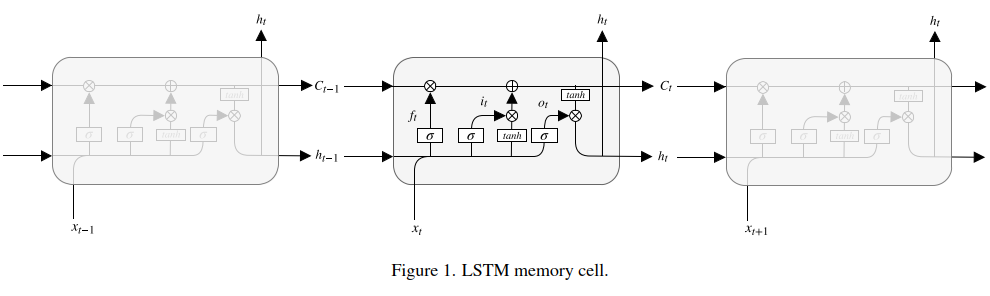

In [ ]:
class VanillaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=100, num_layers=1, dropout=0.0):
        super().__init__()
        # PyTorch warns if dropout > 0 with num_layers == 1; clamp for safety.
        effective_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            bias        = True,
            batch_first = True,   # If True, then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature)
            dropout     = effective_dropout,   # When num_layers == 1, dropout is forced to 0.
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)    # out: (batch, seq, hidden_size)
        last = out[:, -1, :]              # (batch, hidden_size) — final timestep
        return self.fc(last)              # (batch, 1)


# ── Manual baseline: hidden=100, 1 layer, no dropout ─────────────────────────
# Instantiate once per dataset since n_features differs
models = {}

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
    models[ds] = {
        'model':     model,
        'optimizer': optimizer,
    }

# Verify
for ds, contents in models.items():
    model = contents['model']
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{ds} — input_size: {arrays[ds]['X_train'].shape[2]}, parameters: {n_params:,}")
    print(model)


FD001 — input_size: 15, parameters: 46,901
VanillaLSTM(
  (lstm): LSTM(15, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD002_unified — input_size: 21, parameters: 49,301
VanillaLSTM(
  (lstm): LSTM(21, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD002_clustered — input_size: 21, parameters: 49,301
VanillaLSTM(
  (lstm): LSTM(21, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD003 — input_size: 16, parameters: 47,301
VanillaLSTM(
  (lstm): LSTM(16, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD004_unified — input_size: 21, parameters: 49,301
VanillaLSTM(
  (lstm): LSTM(21, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD004_clustered — input_size: 21, parameters: 49,301
VanillaLSTM(
  (lstm): LSTM(21, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


## 6.5 Load Tuned Configurations

Hyperparameter search was performed in `hyperparameter_tuning.ipynb` with
30-config random search and 5-fold engine-grouped CV. The best configuration
per dataset is the one minimising mean validation RMSE across folds.

Here we read the search-result CSVs, derive the best configuration for each
of FD001, FD002_clustered, FD003, and FD004_clustered, and instantiate a
parallel set of "tuned" models alongside the manual baseline.

The same training and evaluation code paths in §7 and §8 will then run for
*both* `models` (manual baseline, hidden=100/1-layer/no-dropout) and
`tuned_models` (per-dataset tuned hyperparameters), enabling a clean
before/after comparison in the report.


In [ ]:
# ── Load best hyperparameters from each tuning CSV ───────────────────────────
TUNING_RESULTS_DIR = 'tuning_results/'
TUNED_DATASETS     = ['FD001', 'FD002_clustered', 'FD003', 'FD004_clustered']

def load_best_config(tune_ds, results_dir=TUNING_RESULTS_DIR, n_folds_required=5):
    """
    Read `search_{tune_ds}.csv`, aggregate fold rows -> per-config mean val RMSE,
    return the row with the lowest mean (only configs with all folds completed).
    """
    csv_path = os.path.join(results_dir, f'search_{tune_ds}.csv')
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"No search CSV found at {csv_path}. "
            f"Run hyperparameter_tuning.ipynb with TUNE_DS='{tune_ds}' first."
        )

    df = pd.read_csv(csv_path)
    agg = df.groupby('config_id').agg(
        hidden_size   = ('hidden_size',   'first'),
        num_layers    = ('num_layers',    'first'),
        dropout       = ('dropout',       'first'),
        learning_rate = ('learning_rate', 'first'),
        batch_size    = ('batch_size',    'first'),
        val_rmse_mean = ('val_rmse',      'mean'),
        val_rmse_std  = ('val_rmse',      'std'),
        n_folds       = ('fold',          'count'),
    ).reset_index()

    complete = agg[agg['n_folds'] == n_folds_required]
    if complete.empty:
        raise ValueError(
            f"No complete configs (with {n_folds_required} folds) in {csv_path}."
        )

    best = complete.sort_values('val_rmse_mean').iloc[0]
    return {
        'config_id'    : int(best['config_id']),
        'hidden_size'  : int(best['hidden_size']),
        'num_layers'   : int(best['num_layers']),
        'dropout'      : float(best['dropout']),
        'learning_rate': float(best['learning_rate']),
        'batch_size'   : int(best['batch_size']),
        'val_rmse_mean': float(best['val_rmse_mean']),
        'val_rmse_std' : float(best['val_rmse_std']),
    }


best_configs = {ds: load_best_config(ds) for ds in TUNED_DATASETS}

print("Best configs from random search (5-fold engine-grouped CV):\n")
print(f"  {'dataset':<18} {'cfg':>3} {'hidden':>6} {'layers':>6} "
      f"{'drop':>5} {'lr':>9} {'bs':>4} {'val_rmse':>9}")
print(f"  {'-'*18} {'-'*3} {'-'*6} {'-'*6} {'-'*5} {'-'*9} {'-'*4} {'-'*9}")
for ds, c in best_configs.items():
    print(f"  {ds:<18} {c['config_id']:>3d} {c['hidden_size']:>6d} "
          f"{c['num_layers']:>6d} {c['dropout']:>5.2f} {c['learning_rate']:>9.1e} "
          f"{c['batch_size']:>4d} {c['val_rmse_mean']:>6.2f}±{c['val_rmse_std']:.2f}")


# ── Instantiate tuned models + custom loaders (per-config batch size) ────────
tuned_models  = {}
tuned_loaders = {}

for ds, cfg in best_configs.items():
    n_features = arrays[ds]['X_train'].shape[2]

    set_seed(SEED)   # deterministic init per model
    model = VanillaLSTM(
        input_size  = n_features,
        hidden_size = cfg['hidden_size'],
        num_layers  = cfg['num_layers'],
        dropout     = cfg['dropout'],
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])
    tuned_models[ds] = {
        'model':     model,
        'optimizer': optimizer,
        'config':    cfg,
    }

    # Tuned models use a per-config batch size — rebuild loaders from existing
    # train/val/test indices (same engine-grouped split as the baseline).
    raw          = arrays[ds]
    full_dataset = CMAPSSDataset(raw['X_train'], raw['y_train'])
    test_dataset = CMAPSSDataset(raw['X_test'],  raw['y_test'])

    tuned_loaders[ds] = {
        'train': DataLoader(Subset(full_dataset, raw['train_idx']),
                            batch_size=cfg['batch_size'], shuffle=True),
        'val':   DataLoader(Subset(full_dataset, raw['val_idx']),
                            batch_size=cfg['batch_size'], shuffle=False),
        'test':  DataLoader(test_dataset,
                            batch_size=cfg['batch_size'], shuffle=False),
    }

print("\nTuned model summary:")
for ds, contents in tuned_models.items():
    n_params = sum(p.numel() for p in contents['model'].parameters())
    n_baseline = sum(p.numel() for p in models[ds]['model'].parameters()) if ds in models else None
    msg = f"  {ds:<18} parameters: {n_params:>9,}"
    if n_baseline is not None:
        ratio = n_params / n_baseline
        msg += f"  (baseline: {n_baseline:,}, ratio {ratio:.2f}×)"
    print(msg)


## 7. Training Loop

Unlike Keras, PyTorch requires an explicit training loop. The key difference from
Keras's `.fit()` is that you manage the gradient lifecycle yourself:
`zero_grad()` clears accumulated gradients, `loss.backward()` computes them,
and `optimizer.step()` applies them. This verbosity is a feature — it gives you
full control, which matters when you later implement custom GNN training procedures.

The loop below tracks train and validation MSE each epoch and restores the best
weights (by validation loss) after training — equivalent to Keras's
`ModelCheckpoint` callback.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    """One full pass over the training DataLoader. Returns mean train loss."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()                  # clear gradients from previous step
        preds = model(X_batch).squeeze(-1)     # (batch,)
        loss  = criterion(preds, y_batch)
        loss.backward()                        # compute gradients
        optimizer.step()                       # update weights

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    """Compute mean validation loss without gradient computation."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds   = model(X_batch).squeeze(-1)
            total_loss += criterion(preds, y_batch).item() * len(y_batch)

    return total_loss / len(loader.dataset)


def run_training(model, ds, epochs=EPOCHS, snapshot_epochs=None, learning_rate=LEARNING_RATE):
    """
    Full training run for a given dataset key.

    Parameters
    ----------
    model           : the model to train (modified in-place; best weights restored at end)
    ds              : dataset key into `loaders`
    epochs          : total epochs to run
    snapshot_epochs : optional iterable of epoch numbers at which to deep-copy
                      the model's state_dict. Used for diagnostic plots that
                      show predictions evolving across training. Has no effect
                      on training itself.
    learning_rate   : Adam learning rate. Defaults to global LEARNING_RATE
                      (used for the manual baseline). Override per-dataset
                      when training tuned models.

    Returns
    -------
    train_losses, val_losses : lists, length `epochs`
    snapshots                : dict mapping epoch -> state_dict (empty if snapshot_epochs is None)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None
    snapshots     = {}
    snapshot_set  = set(snapshot_epochs) if snapshot_epochs is not None else set()

    for epoch in range(1, epochs + 1):
        tr_loss  = train_one_epoch(model, loaders[ds]['train'], optimizer, criterion)
        val_loss = validate(model, loaders[ds]['val'], criterion)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch in snapshot_set:
            snapshots[epoch] = {k: v.detach().clone().cpu()
                                for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train MSE: {tr_loss:.4f} | Val MSE: {val_loss:.4f}")

    model.load_state_dict(best_state)
    print(f"\n  Best val MSE : {best_val_loss:.4f}  (best weights restored)")
    return train_losses, val_losses, snapshots


def plot_loss_curves(train_losses, val_losses, ds):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label='Train MSE', color='steelblue')
    ax.plot(val_losses,   label='Val MSE',   color='darkorange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{ds} — Training and Validation Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PREPROCESSED_DIR, f'{ds}_loss_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Run training for each dataset ─────────────────────────────────────────────
# Snapshots are only captured for FD001, used downstream by the diagnostic
# `predicted vs true` scatter (see next section). The list mirrors the epochs
# that appeared informative in the loss-curve printout: pre-, during, and
# post- the constant-prediction plateau.
SNAPSHOT_EPOCHS = {'FD001': [10, 30, 50, 60, 80, 100]}

train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")
while train_condition not in ['Yes', 'No']:
    print("Invalid input. Please try again. Yes/No")
    train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")

if (train_condition == 'Yes'):
    TRAIN = True
elif (train_condition == 'No'):
    TRAIN = False

if (TRAIN):
    MODELS_DIR = 'saved_models/'
    os.makedirs(MODELS_DIR, exist_ok=True)

    histories       = {}   # ds -> (train_losses, val_losses)  — baseline
    snapshots_by_ds = {}   # ds -> {epoch: state_dict}         — baseline

    # ── Train manual baseline ─────────────────────────────────────────────────
    for ds, contents in models.items():
        model     = contents['model']

        print(f"\n{'='*55}\n  Training BASELINE on {ds}\n{'='*55}")

        train_losses, val_losses, snaps = run_training(
            model, ds, snapshot_epochs=SNAPSHOT_EPOCHS.get(ds))
        plot_loss_curves(train_losses, val_losses, ds)

        histories[ds]       = (train_losses, val_losses)
        snapshots_by_ds[ds] = snaps

        save_path     = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}.pt')
        history_path  = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}_history.pt')

        torch.save(model.state_dict(), save_path)
        torch.save({'train_losses': train_losses,
                    'val_losses':   val_losses}, history_path)

        if snaps:
            snap_path = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}_snapshots.pt')
            torch.save(snaps, snap_path)
            print(f"  Saved snapshots → {snap_path}  ({sorted(snaps.keys())})")

        print(f"  Saved weights → {save_path}")
        print(f"  Saved history → {history_path}")

    # ── Train tuned models (per-dataset hyperparameters from random search) ──
    # We reuse `run_training` but with a few wrinkles:
    #   1. Each tuned model has its own batch size, so it uses `tuned_loaders`
    #      rather than the global `loaders` dict — handled by passing the
    #      loaders explicitly via a tiny shim.
    #   2. The optimizer was already constructed with the tuned learning rate
    #      in §6.5, but `run_training` builds its own — so we monkey-patch
    #      the learning rate by recreating the optimizer with the tuned lr,
    #      and simply override the `loaders` dict for the duration of the call.
    tuned_histories = {}

    for ds, contents in tuned_models.items():
        model = contents['model']
        cfg   = contents['config']

        print(f"\n{'='*55}\n  Training TUNED on {ds}  "
              f"(hs={cfg['hidden_size']}, nl={cfg['num_layers']}, "
              f"do={cfg['dropout']:.2f}, lr={cfg['learning_rate']:.1e}, "
              f"bs={cfg['batch_size']})\n{'='*55}")

        # Temporarily swap loaders[ds] for the tuned-batch-size version
        # so run_training picks up the right DataLoaders, then restore.
        original_loaders = loaders[ds]
        loaders[ds]      = tuned_loaders[ds]
        try:
            train_losses, val_losses, _ = run_training(
                model, ds, learning_rate=cfg['learning_rate'])
        finally:
            loaders[ds] = original_loaders

        plot_loss_curves(train_losses, val_losses, f"{ds}_tuned")
        tuned_histories[ds] = (train_losses, val_losses)

        save_path = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}_tuned.pt')
        torch.save({'state_dict': model.state_dict(), 'config': cfg}, save_path)
        print(f"  Saved tuned weights → {save_path}")
else:
    raise Exception("Execution stopped. We do not desire to train a model and the rest of the notebook has to not execute")


Exception: Execution stopped. We do not desire to train a model and the rest of the notebook has to not execute

These are healthy looking loss curves.

What we are seeing:

Both datasets show the same characteristic shape: a steep drop in the first ~25 epochs where the model learns the bulk of the degradation pattern, followed by a long gradual descent from epoch 25 to 200 where it fine-tunes. The train and validation curves are essentially indistinguishable throughout — they overlap so tightly you can barely tell them apart.

If overfitting would have occured the validation loss would stop decreasing and start climbing back up while the training loss continues downward, creating a visible divergence. That is not what we have here. The two curves move in lockstep all the way to epoch 200, which tells you the model is generalising quite well. 

FD001 vs FD003

FD003 starts with a slightly higher initial loss (~8500 vs ~7400) which makes sense — two concurrent fault modes introduce more variability in the degradation trajectories, making the problem harder at the outset. But the convergence behaviour is essentially the same, and the final loss levels look comparable.

## 7.1. Diagnostic — Predictions across training (FD001)

The FD001 loss curves show a long flat region (epochs ~20–55) at MSE ≈ 1750
followed by a sharp drop near epoch 60. The numerical level of the plateau is
consistent with the model defaulting to a constant prediction near the mean
of the (piecewise-linear) training RUL labels: the MSE of "predict the mean"
on this label distribution is ~1720.

To verify this interpretation, the figure below shows predicted vs. true RUL
on the validation set at six checkpoint epochs spanning the plateau and the
post-plateau regime. During the plateau, predictions form a horizontal cloud
near the label mean — the model is functionally a constant predictor.
After the cliff, predictions rotate toward the diagonal as the model begins
to exploit the temporal sensor signal.

This kind of slow-start / plateau dynamics is a known pathology of LSTM
training, attributable to the forget-gate's default initialisation
(see Jozefowicz et al., 2015, *An Empirical Exploration of Recurrent
Network Architectures*, and Pascanu et al., *On the difficulty of training
recurrent neural networks*). The diagnostic is included for completeness;
it does not affect the final reported metrics, which are taken from the
best-validation checkpoint after the cliff.


In [ ]:
# ── Diagnostic: predicted-vs-true RUL across training epochs (FD001) ─────────
# Reproduces a 2x3 grid of scatter plots showing how predictions evolve
# from the plateau (~constant prediction) through the post-cliff regime.
# Predictions are computed on the validation set so the y-axis range is
# constrained to the engine-grouped held-out fold.

DIAG_DS = 'FD001'

# Try to load snapshots from disk (if training ran with snapshot_epochs set).
snap_path = os.path.join('saved_models/', f'VanillaLSTM_{DIAG_DS}_snapshots.pt')
if not os.path.exists(snap_path):
    raise FileNotFoundError(
        f"No snapshots found at {snap_path}. Re-run the training cell with "
        f"SNAPSHOT_EPOCHS configured for {DIAG_DS!r}."
    )

snapshots = torch.load(snap_path, map_location=DEVICE)
print(f"Loaded {len(snapshots)} snapshots: {sorted(snapshots.keys())}")

# Rebuild a model with the same architecture used during training
# (we read the existing model object out of the `models` dict).
diag_model = models[DIAG_DS]['model']

# Pull val tensors once (no shuffling -> stable order across snapshots)
val_loader = loaders[DIAG_DS]['val']
y_true_all = []
X_all      = []
for X_batch, y_batch in val_loader:
    X_all.append(X_batch)
    y_true_all.append(y_batch)
X_all      = torch.cat(X_all).to(DEVICE)
y_true_all = torch.cat(y_true_all).cpu().numpy()


def predict_with_state(model, state_dict, X):
    """Load weights, run inference, return numpy array of predictions."""
    model.load_state_dict(state_dict)
    model.eval()
    with torch.no_grad():
        return model(X).squeeze(-1).cpu().numpy()


# ── Plot grid ─────────────────────────────────────────────────────────────────
epochs_sorted = sorted(snapshots.keys())
n = len(epochs_sorted)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes).flatten()

# Common axis limits — RUL in [0, 125] after the piecewise-linear cap
ax_max = max(125, float(y_true_all.max()) + 5)
mean_y = float(y_true_all.mean())

for ax, epoch in zip(axes, epochs_sorted):
    y_pred = predict_with_state(diag_model, snapshots[epoch], X_all)

    ax.scatter(y_true_all, y_pred, s=8, alpha=0.35, color='steelblue',
               edgecolors='none')
    ax.plot([0, ax_max], [0, ax_max], color='black', linewidth=0.8,
            linestyle='--', label='y = x')
    ax.axhline(mean_y, color='crimson', linewidth=0.8, linestyle=':',
               label=f'mean(y) ≈ {mean_y:.0f}')

    mse = float(((y_pred - y_true_all) ** 2).mean())
    pred_std = float(y_pred.std())
    ax.set_title(f'Epoch {epoch}  |  Val MSE = {mse:.0f}  |  std(ŷ) = {pred_std:.1f}',
                 fontsize=10)
    ax.set_xlim(0, ax_max)
    ax.set_ylim(0, ax_max)
    ax.set_aspect('equal', adjustable='box')

# Hide any unused axes (if n < nrows*ncols)
for ax in axes[len(epochs_sorted):]:
    ax.set_visible(False)

# Shared labels and one legend
for ax in axes[-ncols:]:
    if ax.get_visible():
        ax.set_xlabel('True RUL')
for r in range(nrows):
    axes[r * ncols].set_ylabel('Predicted RUL')

# Legend on the first visible axis only
axes[0].legend(loc='upper left', fontsize=8, framealpha=0.9)

fig.suptitle(f'{DIAG_DS} — Predictions evolve from constant (plateau) to RUL-aware (post-cliff)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, f'{DIAG_DS}_pred_vs_true_across_epochs.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Quick numerical confirmation: std of predictions should be ~0 during plateau
# and grow toward std(y_true) after the cliff.
print("\n── Prediction-spread diagnostic (val set) ──")
print(f"  std(y_true) = {y_true_all.std():.2f}")
for epoch in epochs_sorted:
    y_pred = predict_with_state(diag_model, snapshots[epoch], X_all)
    print(f"  Epoch {epoch:3d}  std(ŷ) = {y_pred.std():6.2f}  "
          f"mean(ŷ) = {y_pred.mean():6.2f}")


## 8. Evaluation and Results

In [ ]:
# ── RMSE and NASA score on test set: baseline vs tuned ──────────────────────
# Builds a single DataFrame of (dataset, variant, RMSE, score) so the report
# can pull a clean comparison table directly.

results = []  # list of dicts

# ── Manual baseline: all 6 datasets ──────────────────────────────────────────
for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    model.load_state_dict(
        torch.load(f'saved_models/VanillaLSTM_{ds}.pt', map_location=DEVICE)
    )
    y_true, y_pred = evaluate(model, loaders[ds]['test'])
    results.append({
        'dataset' : ds,
        'variant' : 'baseline',
        'rmse'    : rmse(y_true, y_pred),
        'score'   : nasa_score(y_true, y_pred),
    })

# ── Tuned: only the 4 datasets with hyperparameter search ────────────────────
for ds, contents in tuned_models.items():
    cfg = contents['config']
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(
        input_size  = n_features,
        hidden_size = cfg['hidden_size'],
        num_layers  = cfg['num_layers'],
        dropout     = cfg['dropout'],
    ).to(DEVICE)
    payload = torch.load(f'saved_models/VanillaLSTM_{ds}_tuned.pt',
                         map_location=DEVICE)
    model.load_state_dict(payload['state_dict'])
    y_true, y_pred = evaluate(model, tuned_loaders[ds]['test'])
    results.append({
        'dataset' : ds,
        'variant' : 'tuned',
        'rmse'    : rmse(y_true, y_pred),
        'score'   : nasa_score(y_true, y_pred),
    })

results_df = pd.DataFrame(results)

# ── Pivot to side-by-side table ──────────────────────────────────────────────
pivot = results_df.pivot(index='dataset', columns='variant', values=['rmse', 'score'])
# Order datasets as in DATASETS for consistent display
pivot = pivot.reindex(DATASETS)

print(f"Test-set comparison — Vanilla LSTM\n{'='*60}")
print(pivot.round(2).to_string())
print()

# Where both variants exist, compute deltas
both_present = results_df.groupby('dataset').filter(lambda g: len(g) == 2)
if not both_present.empty:
    deltas = both_present.pivot(index='dataset', columns='variant', values=['rmse', 'score'])
    deltas[('rmse',  'delta')] = deltas[('rmse',  'tuned')] - deltas[('rmse',  'baseline')]
    deltas[('score', 'delta')] = deltas[('score', 'tuned')] - deltas[('score', 'baseline')]
    print("Deltas (tuned − baseline; negative is better):")
    print(deltas[[('rmse', 'delta'), ('score', 'delta')]].round(2).to_string())


TypeError: only length-1 arrays can be converted to Python scalars

The RMSE and NASA scores should be compared to da Costa & co. The tables are here:
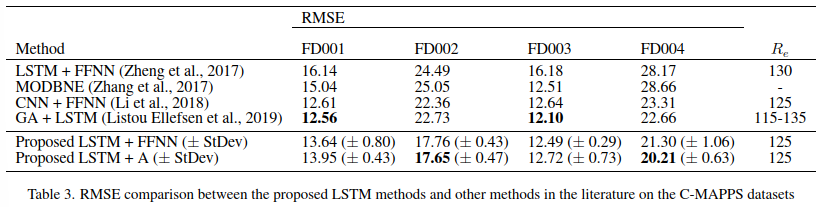

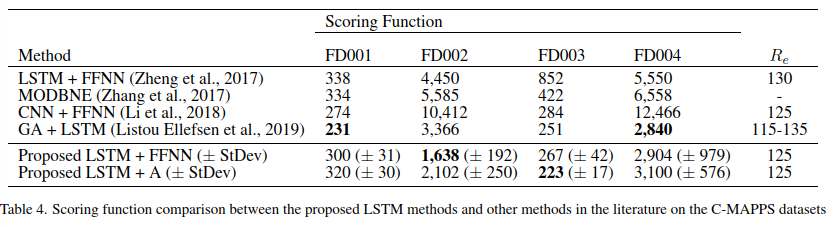